Download Dataset

In [18]:
import gdown
gdown.download('https://drive.google.com/uc?id=1u8GqYeE-11ta1WhrMuTu7CZkJKnHnzxC', 'Mall_Customers.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1u8GqYeE-11ta1WhrMuTu7CZkJKnHnzxC
To: c:\Users\benlo\telebort\Al2\Clustering\Mall_Customers.csv
100%|██████████| 3.98k/3.98k [00:00<?, ?B/s]


'Mall_Customers.csv'

In [19]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\benlo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Phase 1: Importing Dependencies & Read CSV Files

In [20]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
import seaborn as sns
import plotly as py
import plotly.graph_objs as go

In [22]:
# Read csv file
customer_data = pd.read_csv('Mall_Customers.csv')

Phase 2: Data Exploration

In [23]:
# Print first 5 rows of data
customer_data .head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
# Print shape & length of customer data
customer_data .shape, len(df)

((200, 5), 200)

In [25]:
# Print information of dataset
print(customer_data) 

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [26]:
# Check for missing values in customer_data
customer_data .isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Phase 3: KMeans Clustering Models

In [27]:
# Obtain the age & spending score of the customers
X = customer_data[['Age' , 'Spending Score (1-100)']].values

In [28]:
# Import KMeans from sklearn
from sklearn.cluster import KMeans

# Create KMeans Clustering Model for X with n_clusters = 5 and random_state = 42
model = KMeans(n_clusters=5, random_state=42)

# Fit clustering model with X
model.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [29]:
# Print inertia of KMeans model
print('Inertia:', model.inertia_)

Inertia: 23951.044340905457


In [30]:
# Find centroids of KMeans model
print('Centroids:', model.cluster_centers_)

Centroids: [[55.9787234  48.5106383 ]
 [28.68421053 71.5       ]
 [43.42553191 14.65957447]
 [28.3        45.575     ]
 [31.28571429 90.39285714]]


In [31]:
# Using the model, identify which cluster does the following customers belong to
# Example: Customer Z with age 32 and spending score of 50
test_data = [[32, 50]]
print('Customer Z belongs to cluster', model.predict(test_data)[0])
# 1. Customer A with age 20 and spending score of 42
test_data_A = [[20, 42]]
print('Customer A belongs to cluster', model.predict(test_data_A)[0])
# 2. Customer B with age 65 and spending score of 81
test_data_B = [[65, 81]]
print('Customer B belongs to cluster', model.predict(test_data_B)[0])
# 3. Customer C with age 44 and spending score of 100
test_data_C = [[44, 100]]
print('Customer C belongs to cluster', model.predict(test_data_C)[0])
# 4. Customer D with age 59 and spending score of 23
test_data_D = [[59, 23]]
print('Customer D belongs to cluster', model.predict(test_data_D)[0])

Customer Z belongs to cluster 3
Customer A belongs to cluster 3
Customer B belongs to cluster 0
Customer C belongs to cluster 4
Customer D belongs to cluster 2


Phase 4: Plot clustering graph

In [32]:
# Obtain the predicted labels of X and store as labels
labels = model.predict(X)

In [33]:
# Filter data according to their cluster numbers
# From cluster 0 to cluster 4
cluster_0 = X[labels == 0]
cluster_1 = X[labels == 1]
cluster_2 = X[labels == 2]
cluster_3 = X[labels == 3]
cluster_4 = X[labels == 4]

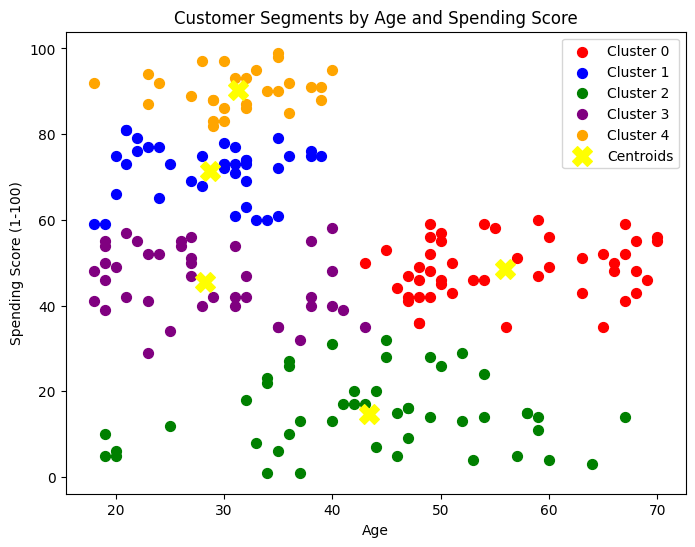

In [34]:
# Plot cluster graph with labels
plt.figure(figsize=(8,6))
plt.scatter(cluster_0[:,0], cluster_0[:,1], s=50, c='red', label='Cluster 0')
plt.scatter(cluster_1[:,0], cluster_1[:,1], s=50, c='blue', label='Cluster 1')
plt.scatter(cluster_2[:,0], cluster_2[:,1], s=50, c='green', label='Cluster 2')
plt.scatter(cluster_3[:,0], cluster_3[:,1], s=50, c='purple', label='Cluster 3')
plt.scatter(cluster_4[:,0], cluster_4[:,1], s=50, c='orange', label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=200, c='yellow', marker='X', label='Centroids')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments by Age and Spending Score')
plt.legend()
plt.show()

Phase 5: Finding the ideal number of clusters

In [35]:
# Declare list of inertia
list_of_inertia = []

# Loop through value of K from 1 - 10, generate the list_of_inertia
for k in range(1 , 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    list_of_inertia.append(km.inertia_)

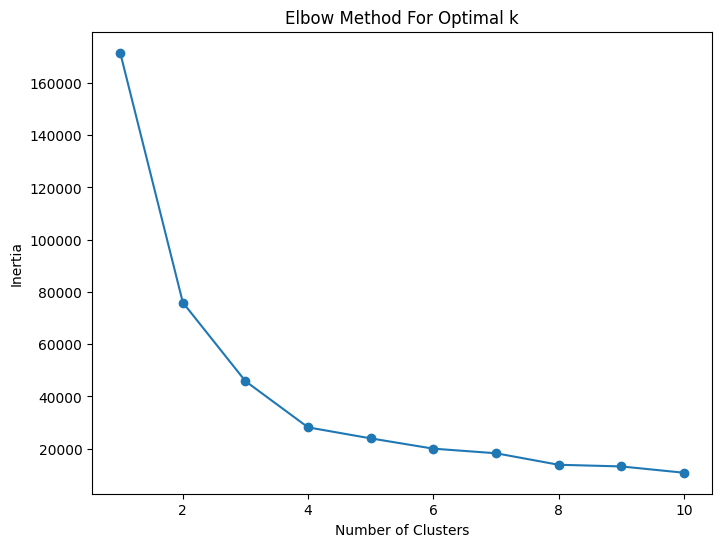

In [36]:
# Plot the graph of inertia against cluster numbers
plt.figure(figsize=(8,6))
plt.plot(range(1,11), list_of_inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

## Advanced Challenge 1

Train a clustering model using the ideal K value found in phase 5

In [37]:
# Create and fit KMeans model
ideal_k = 5  # Replace with the ideal K found from the elbow method
model_ideal = KMeans(n_clusters=ideal_k, random_state=42)
model_ideal.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [38]:
# Print inertia of KMeans model
print('Inertia (ideal K):', model_ideal.inertia_)

Inertia (ideal K): 23951.044340905457


In [39]:
# Obtain the predicted labels of X and store as labels
labels_ideal = model_ideal.predict(X)

In [40]:
# Filter data according to their cluster numbers
clusters_ideal = [X[labels_ideal == i] for i in range(ideal_k)]

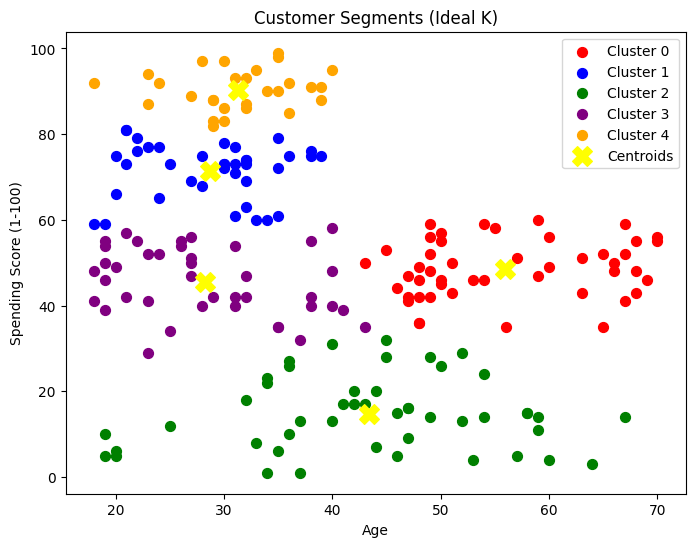

In [41]:
# Plot cluster graph with title, x-labels, y-labels and legends
plt.figure(figsize=(8,6))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'grey', 'pink']
for i, cluster in enumerate(clusters_ideal):
    plt.scatter(cluster[:,0], cluster[:,1], s=50, c=colors[i], label=f'Cluster {i}')
plt.scatter(model_ideal.cluster_centers_[:,0], model_ideal.cluster_centers_[:,1], s=200, c='yellow', marker='X', label='Centroids')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (Ideal K)')
plt.legend()
plt.show()

## Advanced Challenge 2

Train a clustering model for the categories 'annual income' and 'spending score'

In [42]:
# Obtain the X values and save as X1
X1 = customer_data[['Annual Income (k$)' , 'Spending Score (1-100)']].values

In [43]:
# Find the ideal number of clusters
# Declare list of inertia
list_of_inertia1 = []

# Loop through value of K from 1 - 10
for k in range(1 , 11):
    km1 = KMeans(n_clusters=k, random_state=42)
    km1.fit(X1)
    list_of_inertia1.append(km1.inertia_)

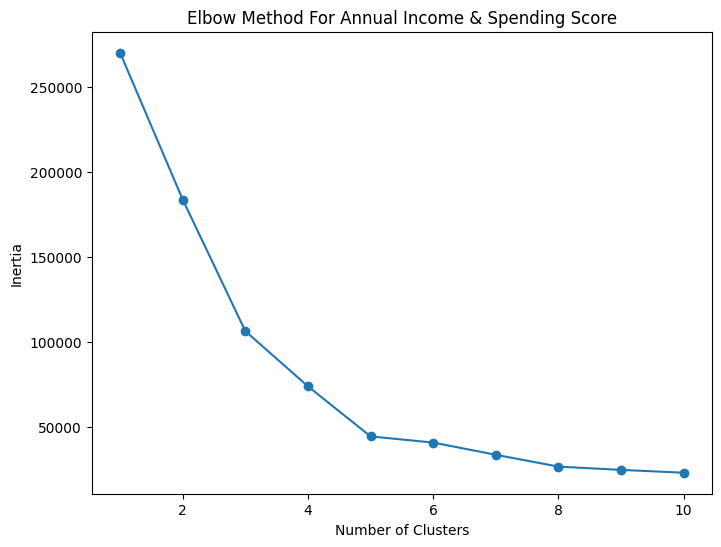

In [44]:
# Plot the graph of inertia against cluster numbers
plt.figure(figsize=(8,6))
plt.plot(range(1,11), list_of_inertia1, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Annual Income & Spending Score')
plt.show()

In [45]:
# Use ideal number of clusters to generate the clustering model
ideal_k1 = 5  # Replace with the ideal K found from the elbow method for X1
model1 = KMeans(n_clusters=ideal_k1, random_state=42)
model1.fit(X1)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [46]:
# Find the inertia of said ideal K value
print('Inertia (ideal K for X1):', model1.inertia_)

Inertia (ideal K for X1): 44448.45544793371


Plot clustering graph

In [47]:
# Obtain the predicted labels of X1 and store as labels
labels1 = model1.predict(X1)

In [48]:
# Filter data according to their cluster numbers
clusters1 = [X1[labels1 == i] for i in range(ideal_k1)]

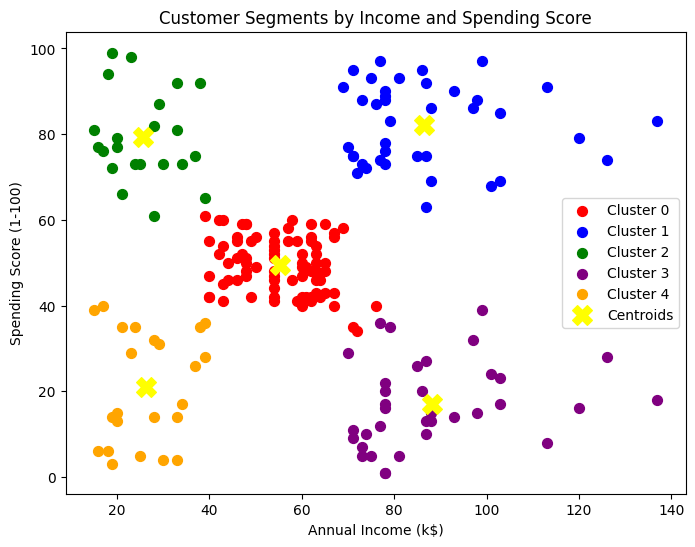

In [49]:
# Plot cluster graph with labels
plt.figure(figsize=(8,6))
colors1 = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'grey', 'pink']
for i, cluster in enumerate(clusters1):
    plt.scatter(cluster[:,0], cluster[:,1], s=50, c=colors1[i], label=f'Cluster {i}')
plt.scatter(model1.cluster_centers_[:,0], model1.cluster_centers_[:,1], s=200, c='yellow', marker='X', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments by Income and Spending Score')
plt.legend()
plt.show()

## Advance Challenge 3

Use the python package kneed to try and locate the ideal number of clusters for advanced challenge 2. You may refer to [this kaggle project](https://realpython.com/k-means-clustering-python/#choosing-the-appropriate-number-of-clusters:~:text=Remove%20ads-,Choosing%20the%20Appropriate%20Number%20of%20Clusters,-In%20this%20section) to complete the challenge.

In [50]:
!pip install --upgrade kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\benlo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [51]:
# Import KneeLocator from kneed
from kneed import KneeLocator

# Locate the number of clusters
kneedle = KneeLocator(range(1,11), list_of_inertia1, S=1.0, curve='convex', direction='decreasing')
print('Optimal number of clusters according to kneed:', kneedle.elbow)

Optimal number of clusters according to kneed: 5
